<div style="font-size: 28px; font-weight: bold; text-align: center; margin-bottom: 20px;">
    Отчёт по лабораторной работе
</div>

<div style="font-size: 20px; margin-bottom: 5px;">
    <b>Дисциплина:</b> <i>Цифровая обработка сигналов</i>
</div>

<div style="font-size: 20px; margin-bottom: 5px;">
    <b>Лабораторная работа №2:</b> <i>Декодирование DTMF сигнала</i>
</div>


<hr>

<div style="font-size: 20px; margin-bottom: 15px;">
    <b>Вариант:</b> <i>10</i>
</div>

<div style="font-size: 20px; margin-bottom: 5px;">
    <b>Преподаватель:</b> Рыбин Сергей Витальевич
</div>

<div style="font-size: 20px; margin-bottom: 5px;">
    <b>Студент:</b> Рябой Евгений Э., группа М4121
</div>

<div style="font-size: 20px; margin-bottom: 10px;">
    <b>Дата выдачи:</b> 07.11.2025 
    <br>
    <b>Дата исполнения:</b> 24.11.2025
</div>

<hr>


## **Постановка задачи**


**Входные данные**: аудио сигнал $x$ с частотой дискретизации $F_d$ = 44100 Hz, 16 Bit, Mono, PCM wave file

В сигнале $x$ с помощью DTMF кодирования прописана последовательность различных цифр (и управляющих клавиш) телефона.\
Длина каждого элемента звуковой последовательности 200 mc, паузы между ними по 100 mc.

**Задача**: С помощью алгоритм Герцеля декодировать сигнал и восстановить исходную последовательность.


## **Описание системы тонального набора**

1.  DTMF (Dual Tone Multi Frequency) — система двухтонового кодирования, аналогичная тоновому набору номера в телефонах.
2.  Система сигналов DTMF включает восемь тонов, которые были специально подобраны таким образом, чтобы передаваться через телефонную сеть
без затухания и с минимальным воздействием друг на друга.
3.  Поскольку эти звуковые сигналы попадают в частотный диапазон человеческого голоса, было проведено деление тонов на две группы, высоко и
низкочастотную, чтобы голос не воспринимался как набор. Ниже приведена таблица DTMF тонов
4.  В таблице 1 приведены DTMF тоны различных цифр (и управляющих клавиш) телефона и соответствующих им пар частот.

|            | **1209 Hz** | **1336 Hz** | **1477 Hz** | **1633 Hz** |
| :--------: | :---------: | :---------: | :---------: | :---------: |
| **697 Hz** |      1      |      2      |      3      |      A      |
| **770 Hz** |      4      |      5      |      6      |      B      |
| **852 Hz** |      7      |      8      |      9      |      C      |
| **941 Hz** |      *      |      0      |      #      |      D      |


## 0 Импорты

In [5]:
import os
import wave
from math import gcd


import librosa
import numpy as np
import IPython.display as ipd
import matplotlib.pyplot as plt
from scipy.signal import freqz, firwin, lfilter


# Игнорируем предупреждения
from warnings import filterwarnings
filterwarnings("ignore")

In [6]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn-v0_8-whitegrid')  # Стильная сетка
plt.rcParams['figure.figsize'] = (10, 5)  # Размер по умолчанию
plt.rcParams['font.size'] = 10            # Размер шрифта
plt.rcParams['axes.labelsize'] = 12       # Размер подписей осей
plt.rcParams['axes.titlesize'] = 14       # Размер заголовков

# Для еще лучшего качества (опционально)
plt.rcParams['figure.dpi'] = 150          # Разрешение
plt.rcParams['savefig.dpi'] = 300         # Разрешение при сохранении
plt.rcParams['lines.linewidth'] = 1.5     # Толщина линий

In [7]:
import sys
print(f"Python=={sys.version.split()[0]}")

Python==3.12.12


In [8]:
def print_versions(*modules):
    for m in modules:
        print(f"{m.__name__}=={m.__version__}")

print_versions(librosa, plt.matplotlib, np)

librosa==0.11.0
matplotlib==3.10.7
numpy==2.2.6


## 1 Выполнение работы

В качестве тестового входного сигнала для лабораторной работы используется фрагмент произведения: \
**Sergei Rachmaninoff — Piano Concerto No. 2 in C Minor, Op. 18: III. Allegro scherzando**


### 1.0 Просмотр информации о файле

In [69]:
def print_wav_info(filepath: str) -> None:
    if not os.path.isfile(filepath):
        raise FileNotFoundError(f"Файл '{filepath}' не найден.")

    with wave.open(filepath, 'rb') as wav_file:
        sample_rate = wav_file.getframerate()   # Частота дискретизации (Гц)
        num_channels = wav_file.getnchannels()  # Количество каналов
        sample_width = wav_file.getsampwidth()  # Размер сэмпла в байтах
        bit_depth = sample_width * 8            # Глубина квантования (бит)
        num_frames = wav_file.getnframes()      # Общее количество кадров (сэмплов на канал)

        print(f"Частота дискретизации: {sample_rate} Гц")
        print(f"Количество каналов: {num_channels}")
        print(f"Размер сэмпла: {sample_width} байт(а)")
        print(f"Глубина квантования: {bit_depth} бит")
        print(f"Общее количество сэмплов: {num_frames}")
        print(f"Длительность: {num_frames / sample_rate:.2f} секунд")

In [70]:
path_audio_file = "data/DTMF_Lab10.wav"
print_wav_info(filepath=path_audio_file)

Частота дискретизации: 44100 Гц
Количество каналов: 1
Размер сэмпла: 2 байт(а)
Глубина квантования: 16 бит
Общее количество сэмплов: 211680
Длительность: 4.80 секунд


### 1.1 Считывание аудиосигнала

Основные параметры [`librosa.load`](https://librosa.org/doc/0.11.0/generated/librosa.load.html)

Сигнатура:  
`librosa.load(path, *, sr=22050, mono=True, offset=0.0, duration=None, dtype=np.float32, res_type='soxr_hq')`

1. **`path`** - путь/источник аудио (строка, `pathlib.Path`, файловый объект и т. п.)
2. **`sr`** - целевая частота дискретизации (**по умолчанию `22050` Гц**; `None` - сохранить "родную" частоту файла)
3. **`mono`** - сводить в моно (**по умолчанию `True`**)
4. **`offset`** - начать чтение с этой секунды (**по умолчанию `0.0`**)
5. **`duration`** - длительность чтения в секундах (**по умолчанию `None`**; до конца файла)
6. **`dtype`** - тип выходного массива (**по умолчанию `np.float32`**)
7. **`res_type`** - тип ресемплера (**по умолчанию `'soxr_hq'`**)

Возвращает
1. **`y`** - аудиоданные (`numpy.ndarray`, форма `(n,)` для моно или `(…, n)` для мультиканала при `mono=False`)
2. **`sr`** - фактическая частота дискретизации (`int`)


In [71]:
audio_data, original_sample_rate = librosa.load(
    path=path_audio_file, 
    sr=None, 
    mono=True, 
    offset=0.0, 
    duration=100.0, 
    res_type='soxr_vhq'
)

print(f"Частота дискретизации: {original_sample_rate} Гц")
print(f"Тип данных после загрузки: {audio_data.dtype}")
print(f"Диапазон амплитуд: [{audio_data.min():.4f}, {audio_data.max():.4f}]")
print(f"Общее количество сэмплов: {len(audio_data)}")
print(f"Длительность: {len(audio_data) / original_sample_rate:.2f} секунд")

Частота дискретизации: 44100 Гц
Тип данных после загрузки: float32
Диапазон амплитуд: [-0.2512, 0.2512]
Общее количество сэмплов: 211680
Длительность: 4.80 секунд


#### Визуализируем и прослушаем

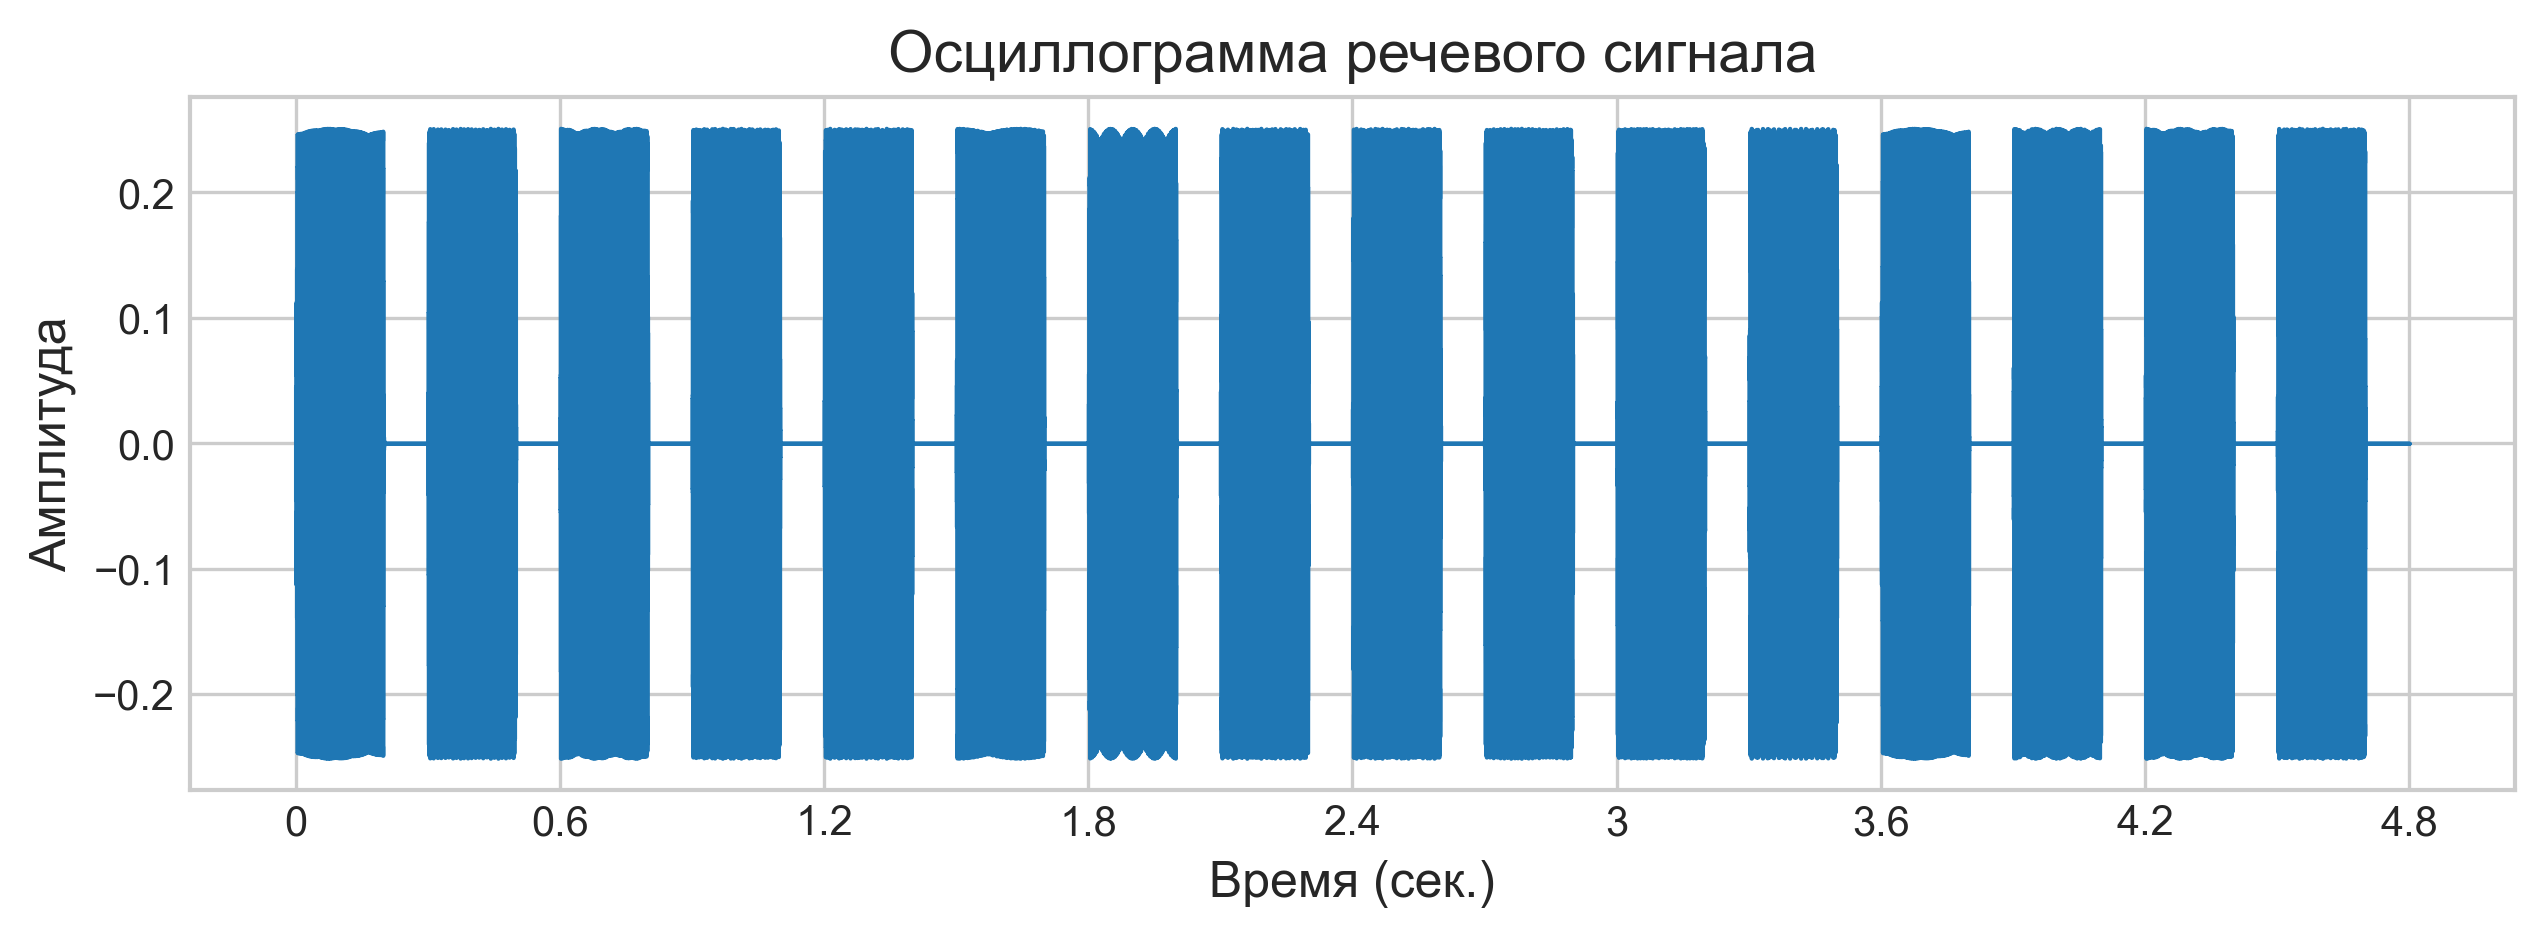

Оригинал (44100 Гц):


In [72]:
plt.figure(figsize=(10, 3))
librosa.display.waveshow(audio_data, sr=original_sample_rate)
plt.title("Осциллограмма речевого сигнала")
plt.xlabel("Время (сек.)")
plt.ylabel("Амплитуда")
plt.show()

print(f"Оригинал ({original_sample_rate} Гц):")
ipd.Audio(data=audio_data, rate=original_sample_rate)

##### Функции для спектрограммы

In [73]:
# Строим и визуализируем спектрограмму (с параметрами по умолчанию)
def Spectrogram(data, stitle, sr=44100):
    # data - исходные данные
    # stitle - название сигнала 
    # Строим спектрограмму    
    X = librosa.stft(data)
    Xdb = librosa.amplitude_to_db(abs(X))

    # Визуализируем спектрограмму
    fig, ax = plt.subplots(figsize=(14, 3))
    img = librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='linear', ax=ax)
    ax.set(title=stitle + ' Спектрограмма. Линейный масштаб')
    fig.colorbar(img, ax=ax, format="%+2.f dB")
    plt.ylabel("Частота (Гц)")
    
    fig, ax = plt.subplots(figsize=(14, 3))
    img = librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='log', ax=ax)
    ax.set(title=stitle + ' Спектрограмма. Логарифмический масштаб')
    fig.colorbar(img, ax=ax, format="%+2.f dB")
    plt.ylabel("Частота (Гц)")
    plt.xlabel("Время (сек.)")

In [74]:
def plot_spectra(
        data, 
        name="Сигнал", 
        color="tab:blue", 
        n_fft=4096, 
        sr=22050,
        start=5000,
        plot_instant=True, 
        plot_log=True,
        xlim_min=None,    # нижний предел частоты
        xlim_max=None     # верхний предел частоты
    ):
    
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

    # Мгновенный спектр
    if plot_instant:
        sp_inst = np.abs(librosa.stft(data[start:start+n_fft], n_fft=n_fft, hop_length=n_fft+1))
        sp_inst_log = 20*np.log10(sp_inst / np.max(sp_inst))

    # Средний спектр
    sp = np.abs(librosa.stft(data, n_fft=n_fft, hop_length=n_fft//2))
    sp_mean = np.mean(sp, axis=1)
    sp_mean_log = 20*np.log10(sp_mean / np.max(sp_mean))

    # Выбор количества подграфиков
    num_plots = (1 if plot_instant else 0) + (1 if plot_instant and plot_log else 0) \
                + 1 + (1 if plot_log else 0)

    plt.figure(figsize=(18, 4 * num_plots))

    plot_index = 1

    def set_xlim():
        if xlim_min is not None or xlim_max is not None:
            plt.xlim(
                xlim_min if xlim_min is not None else 0,
                xlim_max if xlim_max is not None else freqs[-1]
            )

    # Мгновенный линейный
    if plot_instant:
        plt.subplot(num_plots, 1, plot_index)
        plt.title(f"{name} — Мгновенный амплитудный спектр")
        plt.plot(freqs, sp_inst, color=color)
        plt.ylabel("Амплитуда")
        plt.grid(True)
        set_xlim()
        plot_index += 1

    # Мгновенный лог
    if plot_instant and plot_log:
        plt.subplot(num_plots, 1, plot_index)
        plt.title(f"{name} — Мгновенный логарифмический спектр")
        plt.plot(freqs, sp_inst_log, color=color)
        plt.ylabel("Амплитуда (дБ)")
        plt.grid(True)
        set_xlim()
        plot_index += 1

    # Средний линейный
    plt.subplot(num_plots, 1, plot_index)
    plt.title(f"{name} — Средний амплитудный спектр")
    plt.plot(freqs, sp_mean, color=color)
    plt.ylabel("Амплитуда")
    plt.xlabel("Частота (Гц)")
    plt.grid(True)
    set_xlim()
    plot_index += 1

    # Средний лог
    if plot_log:
        plt.subplot(num_plots, 1, plot_index)
        plt.title(f"{name} — Средний логарифмический спектр")
        plt.plot(freqs, sp_mean_log, color=color)
        plt.ylabel("Амплитуда (дБ)")
        plt.xlabel("Частота (Гц)")
        plt.grid(True)
        set_xlim()

    plt.tight_layout()
    plt.show()

##### Демонстрация

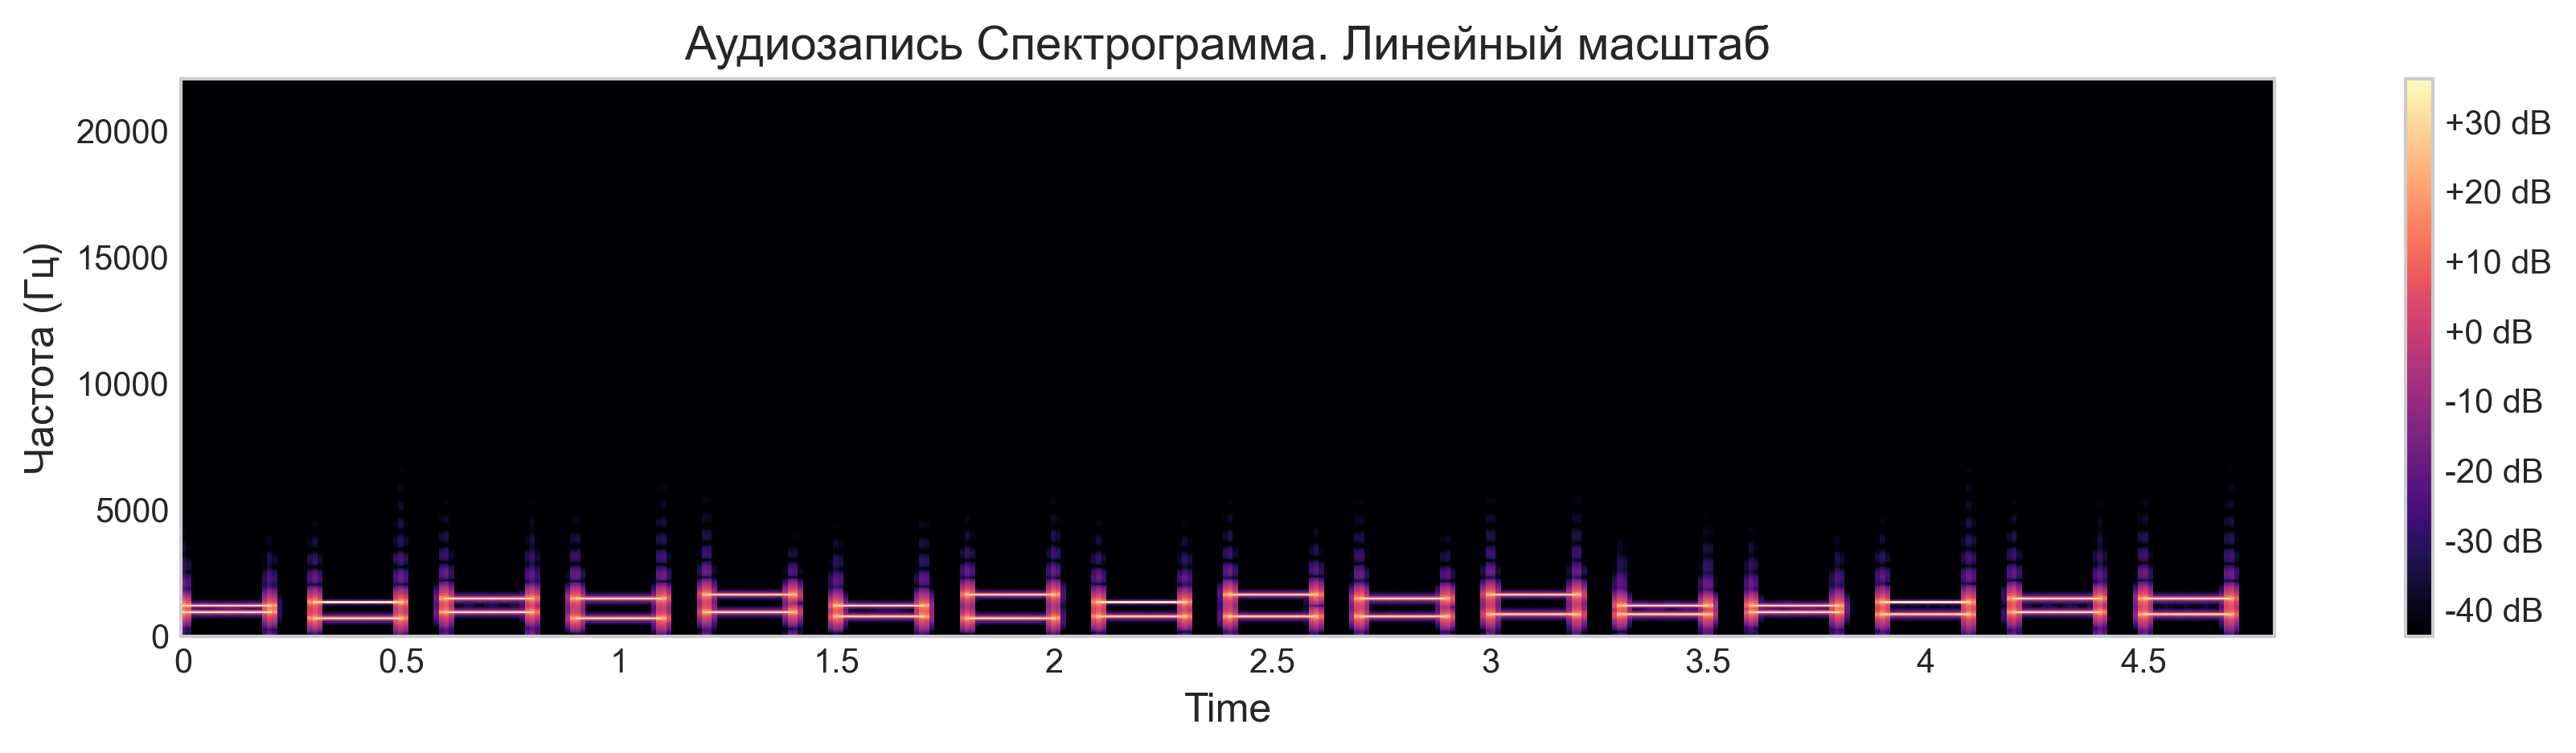

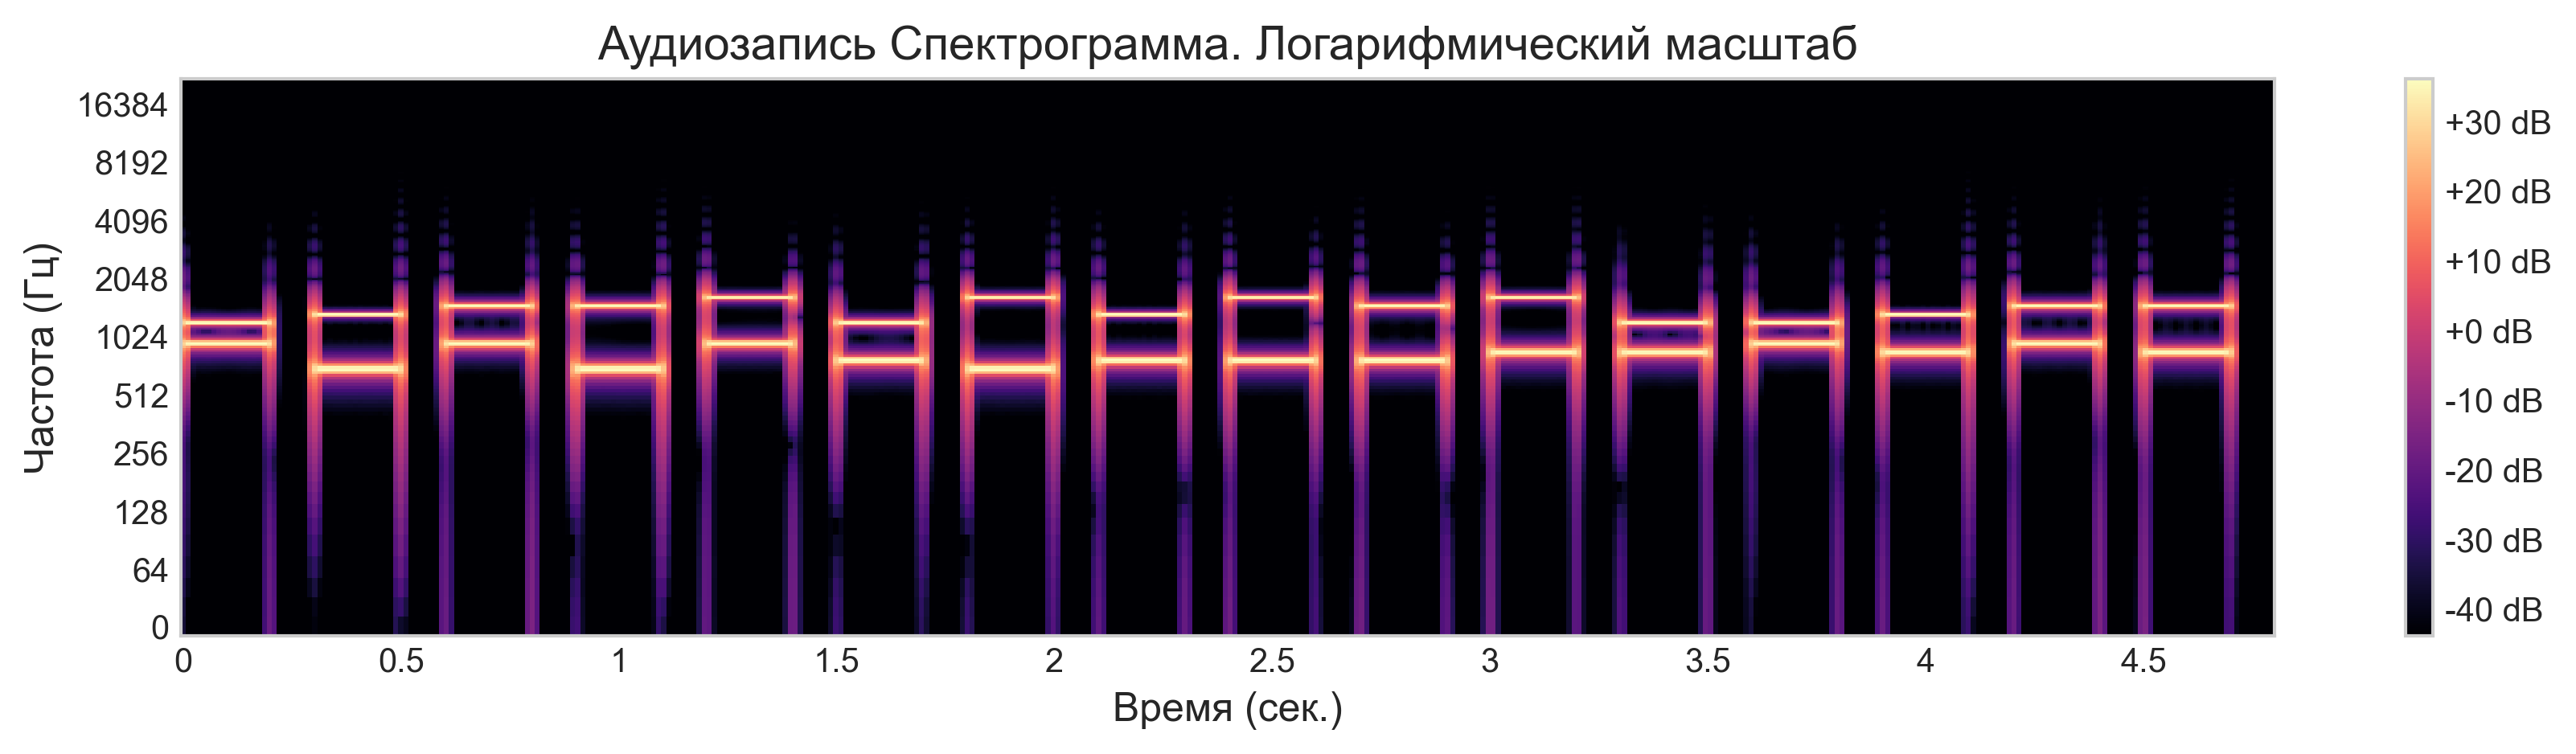

In [75]:
Spectrogram(audio_data, 'Аудиозапись', sr=original_sample_rate)

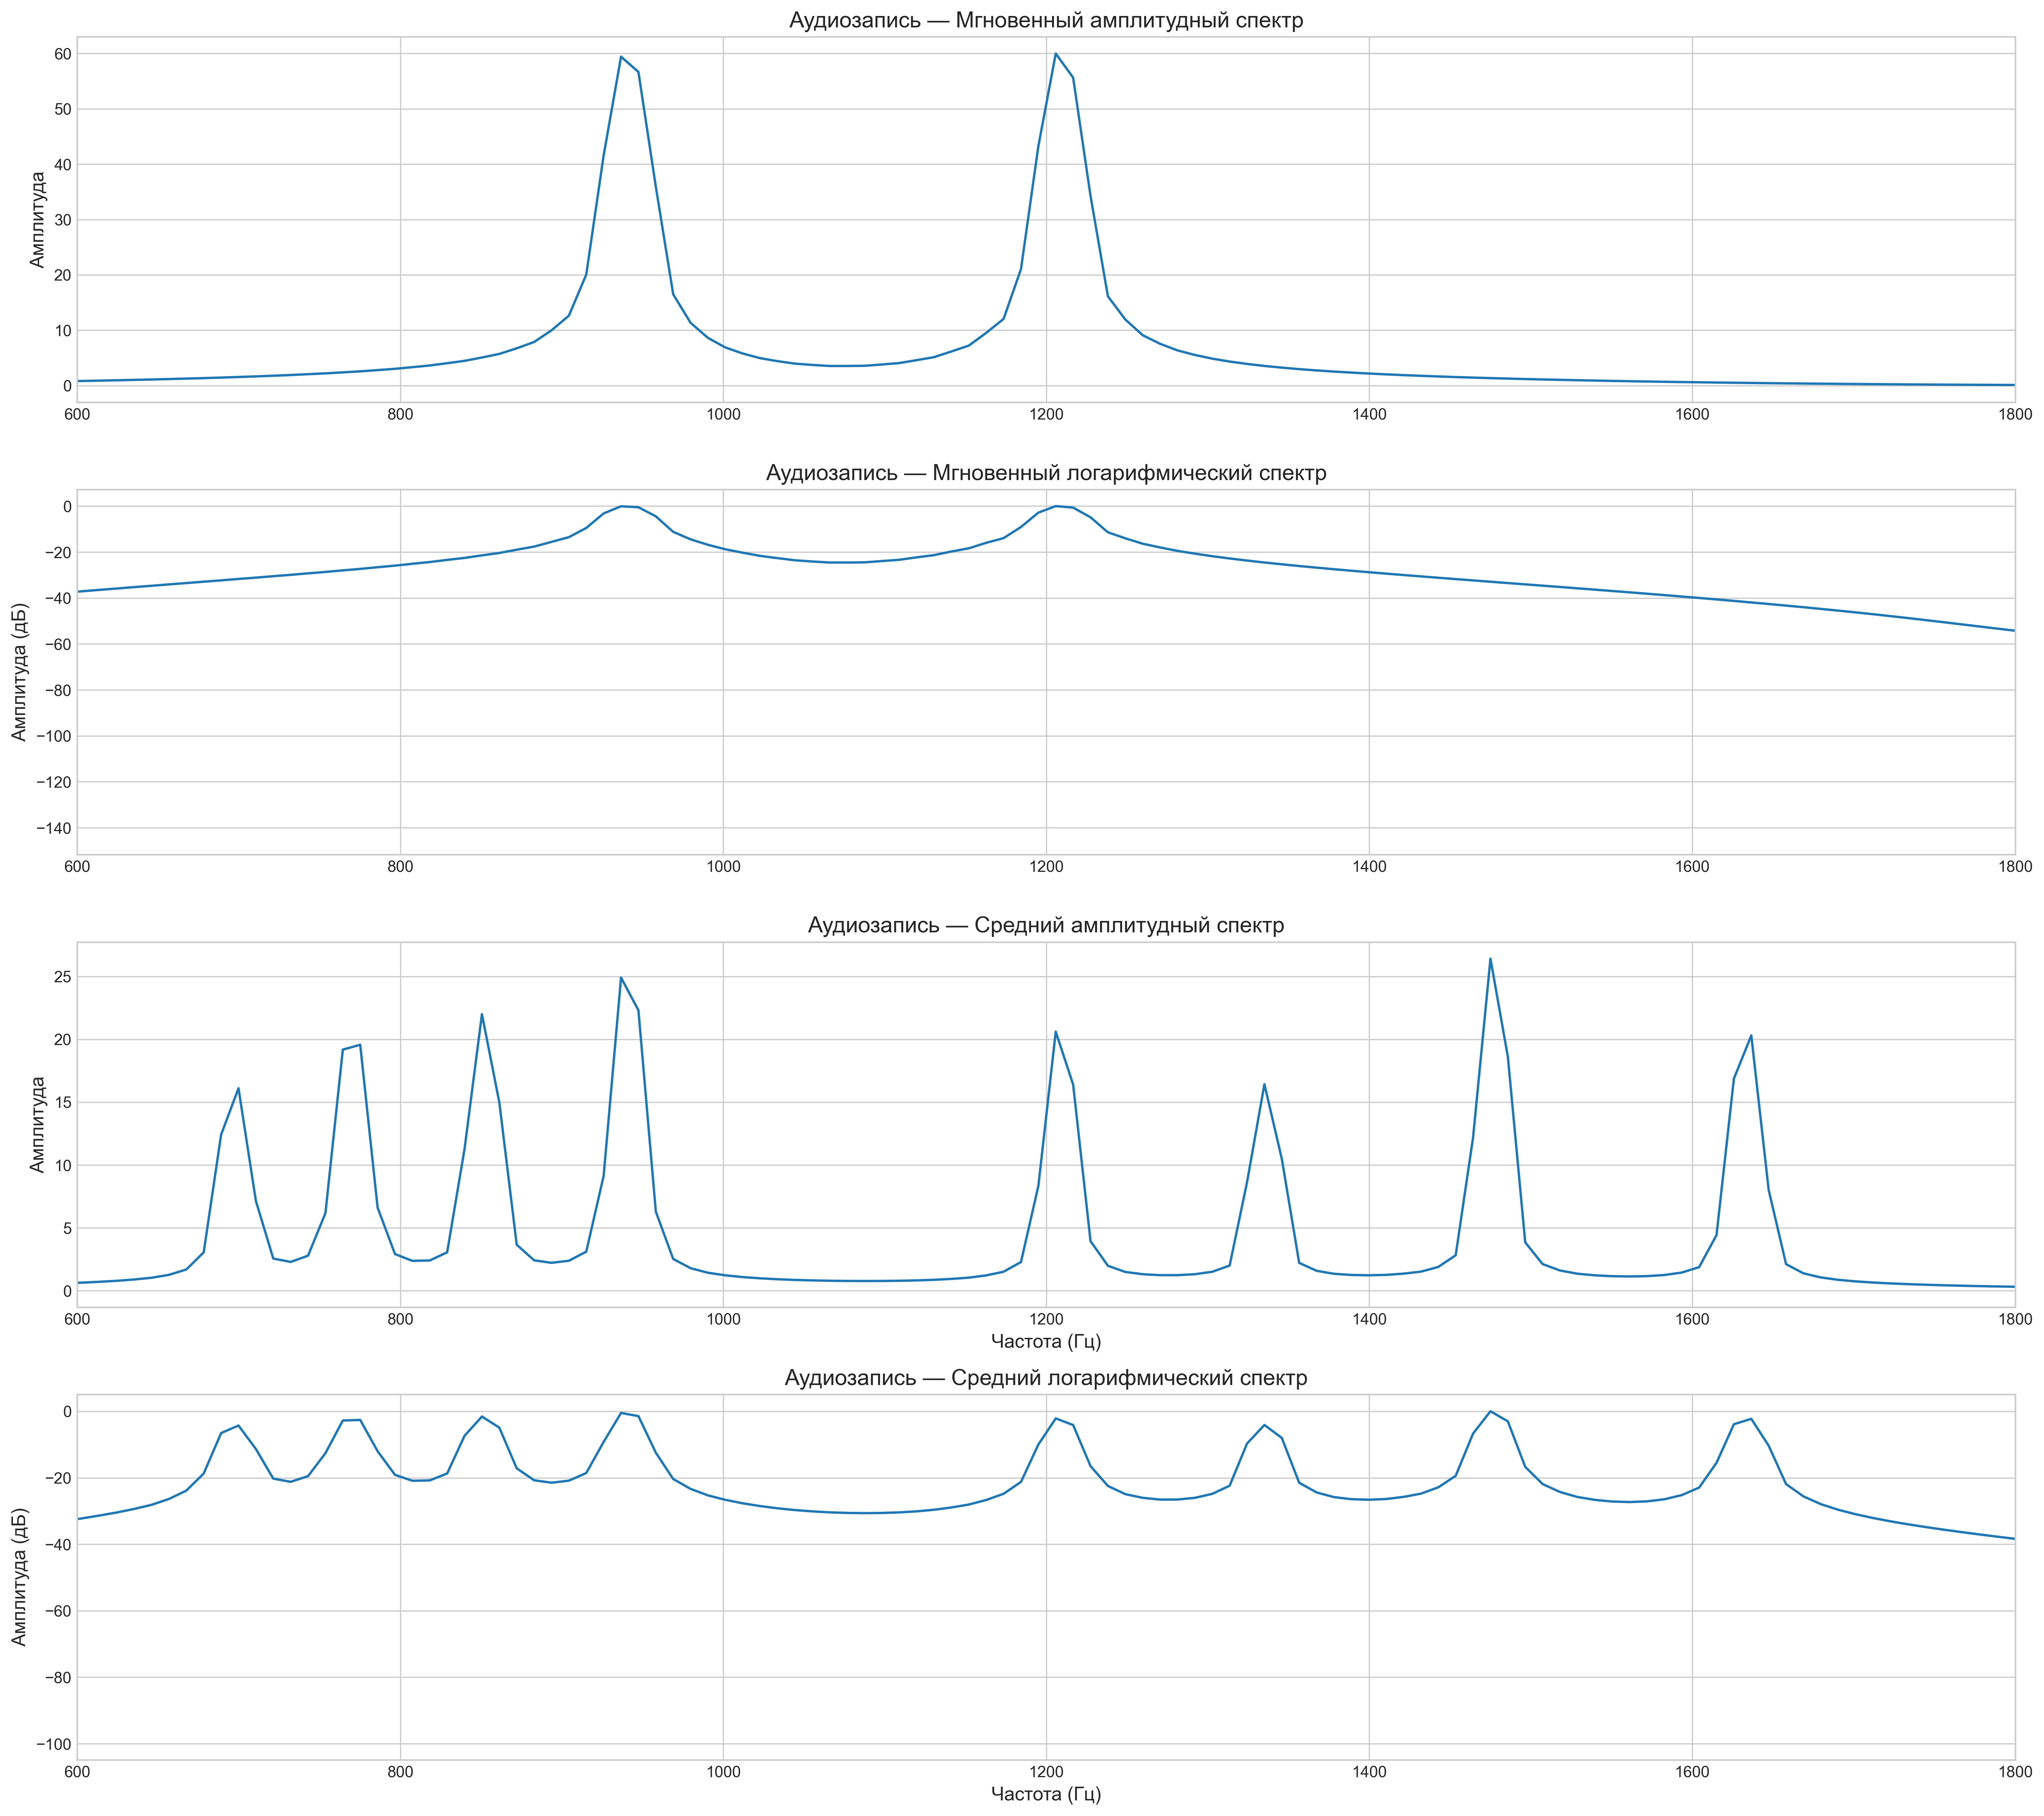

In [76]:
plot_spectra(audio_data, 
             name="Аудиозапись", 
             color="tab:blue", 
             sr=original_sample_rate,
             start=0,
             plot_instant=True, 
             plot_log=True,
             xlim_min=600, 
             xlim_max=1800
             )

### 1.2 Реализация


Нам было сказано, что длительность фрагмента с звуком 200 мс, а пауза между фрагментами 100 мс

**Алгоритм Герцеля** (Goertzel algorithm)

Для вычисления одного спектрального компонента дискретного сигнала $x_n$ длины $N$ по частоте с индексом $k$:

Рекуррентная формула для вычисления промежуточных значений $s_n$:

$$
s_n = 2 \cos \left( \frac{2 \pi k}{N} \right) s_{n-1} - s_{n-2} + x_n
$$

где $ n = 0, 1, \ldots, N-1 $, частотные компоненты дискретного преобразования Фурье,\
а $x_k, k = 0, 1, \ldots, N-1 $, частотные компоненты дискретного преобразования Фурье.

Начальные условия:

$$
s_{-1} = 0, \quad s_{-2} = 0
$$



Вычислим мощность сигнала без учета фазы, используя:

$$
|X_k|^2 = S^2_{N-1} - 2 \cos \left( \frac{2 \pi k}{N} \right) S_{N-1} S_{N-2} + S^2_{N-2}
$$




In [77]:
# Таблица частот DTMF (телефонные кнопки)
LOW_FREQS = [697.0, 770.0, 852.0, 941.0]        # Низкие частоты (строки)
HIGH_FREQS = [1209.0, 1336.0, 1477.0, 1633.0]   # Высокие частоты (столбцы)
BUTTONS = [
    ["1", "2", "3", "A"],
    ["4", "5", "6", "B"],
    ["7", "8", "9", "C"],
    ["*", "0", "#", "D"]
]

def goertzel(x, fs, f_target):
    """
    Алгоритм Герцеля для вычисления мощности спектрального компонента X_k
    """
    N = len(x)                          
    k = int(0.5 + (N * f_target) / fs)  # индекс частоты k
    omega = (2.0 * np.pi * k) / N       # (2 pi k)/ N
    cos_term = 2.0 * np.cos(omega)      # 2 cos((2 pi k)/ N)

    S_nm1 = 0.0 # S_{n-1}
    S_nm2 = 0.0 # S_{n-2}

    # Рекуррентная формула: S_n = 2 cos((2 pi k)/ N) * S_{n-1} – S_{n-2} + x_n
    for x_n in x:
        S_n = cos_term * S_nm1 - S_nm2 + x_n
        S_nm2 = S_nm1
        S_nm1 = S_n

    # Мощность |X_k|^2 по формуле:
    power = S_nm1**2 - cos_term * S_nm1 * S_nm2 + S_nm2**2
    return power

def detect_dtmf(samples, sample_rate):
    """Определение символа DTMF по фрагментам звукового сигнала"""
    low_powers = [goertzel(samples, sample_rate, f) for f in LOW_FREQS]
    high_powers = [goertzel(samples, sample_rate, f) for f in HIGH_FREQS]

    low_freq_index = np.argmax(low_powers)
    high_freq_index = np.argmax(high_powers)

    return BUTTONS[low_freq_index][high_freq_index]


In [94]:
tone_duration = int(0.2 * original_sample_rate)     # 200 ms фрагменты
pause_duration = int(0.1 * original_sample_rate)    # 100 ms паузы
num_segments = int(len(audio_data) / original_sample_rate / 0.3)

position_cursor = 0
decoded_symb = []
for _ in range(num_segments):
    start_idx = position_cursor
    end_idx = position_cursor + tone_duration

    tone_segment = audio_data[start_idx:end_idx]
    decoded_symb.append(detect_dtmf(samples=tone_segment, sample_rate=original_sample_rate))

    position_cursor = end_idx + pause_duration

print("Результат:\n\n", decoded_symb)


Результат:

 ['*', '2', '#', '3', 'D', '4', 'A', '5', 'B', '6', 'C', '7', '*', '8', '#', '9']


# Выводы

1.  Благодаря алгоритму Гёрцеля можно вполне экономно найти известные частотные компоненты в сигнале, при помощи мощности
2.  Бесспорно является эффективным для распознования DTMF-синалов
3.  Точность метода зависит от правильной сегментации аудио. Необходимо чётко отделять участки, содержащие тон, от пауз или шумовых фрагментов, например, при помощи VAD